In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "GLDS-168_rna_seq_Mmus_C57-6J_LVR_RR1_BSL_noERCC_Rep5_M10.isoforms.results",
    sep="\t"
)

print(df.shape)

df.head()

(141954, 8)


,transcript_id,gene_id,length,effective_length,expected_count,TPM,FPKM,IsoPct
0,ENSMUST00000000001,ENSMUSG00000000001,3262,3077.91,8486.0,14.65,33.38,100.00
1,ENSMUST00000000003,ENSMUSG00000000003,902,717.91,0.0,0.00,0.00,0.00
2,ENSMUST00000114041,ENSMUSG00000000003,697,512.91,0.0,0.00,0.00,0.00
3,ENSMUST00000000028,ENSMUSG00000000028,2143,1958.91,63.0,0.17,0.39,97.66
4,ENSMUST00000096990,ENSMUSG00000000028,1747,1562.91,0.0,0.00,0.00,0.00


In [2]:
top_genes = df.sort_values("TPM", ascending=False)

top_genes.head(20)

,transcript_id,gene_id,length,effective_length,expected_count,TPM,FPKM,IsoPct
120116,ENSMUST00000174924,ENSMUSG00000099021,300,119.35,7252871.99,323010.47,735860.69,100.00
120345,ENSMUST00000175032,ENSMUSG00000099250,300,119.35,5275955.88,234967.48,535287.07,100.00
91001,ENSMUST00000083103,ENSMUSG00000065037,331,148.88,1710633.03,61070.88,139127.57,100.00
113088,ENSMUST00000175096,ENSMUSG00000092837,319,137.36,558056.21,21594.59,49195.33,100.00
41763,ENSMUST00000031314,ENSMUSG00000029368,2034,1849.91,5907056.37,16972.29,38665.12,99.94
116720,ENSMUST00000179621,ENSMUSG00000096349,164,15.94,35833.59,11951.85,27227.91,100.00
109029,ENSMUST00000157463,ENSMUSG00000088088,271,92.66,143391.57,8225.24,18738.19,100.00
113789,ENSMUST00000178333,ENSMUSG00000093815,164,15.94,22428.56,7480.51,17041.60,100.00
116592,ENSMUST00000101833,ENSMUSG00000096243,141,7.62,10150.64,7078.61,16126.02,100.00
114410,ENSMUST00000177864,ENSMUSG00000094377,141,7.62,9931.36,6925.70,15777.66,100.00


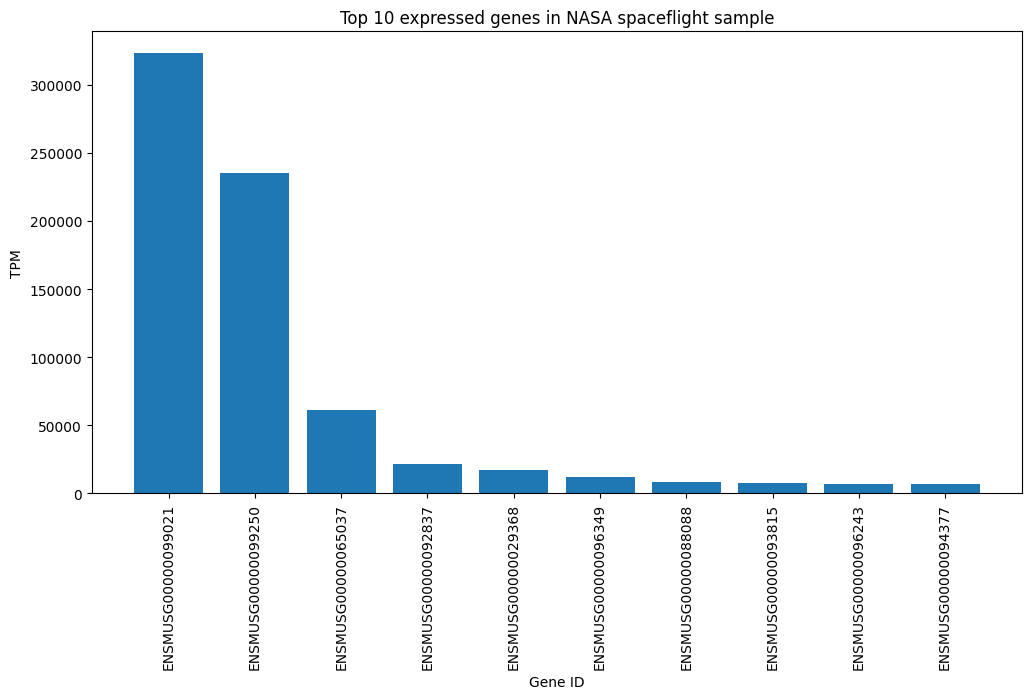

In [3]:
top10 = top_genes.head(10)

plt.figure(figsize=(12,6))

plt.bar(top10["gene_id"], top10["TPM"])

plt.xticks(rotation=90)

plt.title("Top 10 expressed genes in NASA spaceflight sample")

plt.ylabel("TPM")

plt.xlabel("Gene ID")

plt.show()

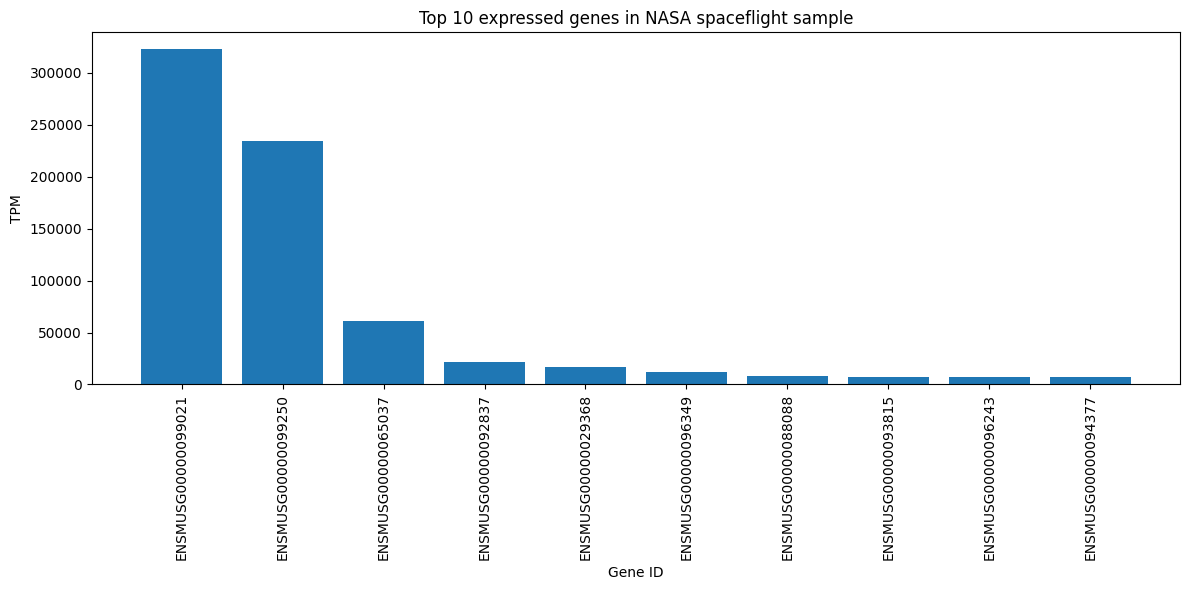

In [6]:
plt.figure(figsize=(12,6))

plt.bar(top10["gene_id"], top10["TPM"])

plt.xticks(rotation=90)

plt.title("Top 10 expressed genes in NASA spaceflight sample")

plt.ylabel("TPM")

plt.xlabel("Gene ID")

plt.tight_layout()

plt.savefig("figures/top10_spaceflight_genes.png")

plt.show()

In [5]:
import os
os.makedirs("figures", exist_ok=True)

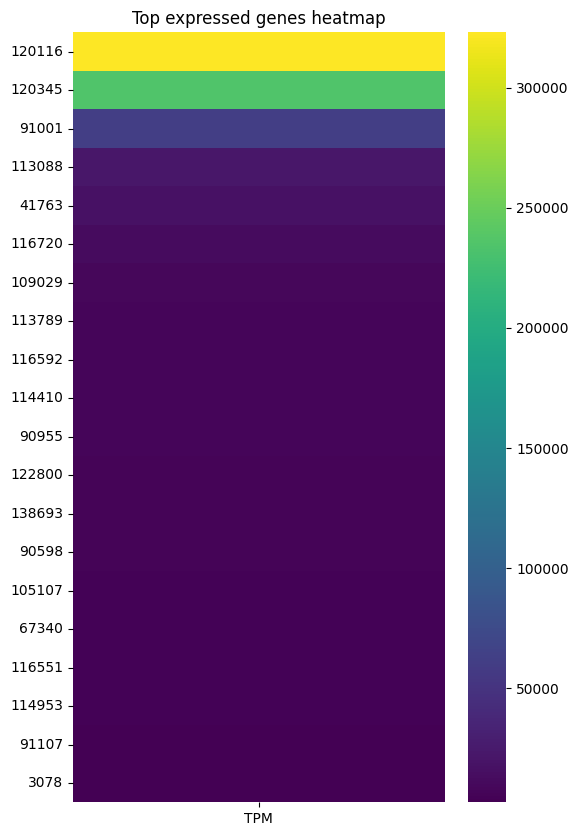

In [7]:
heatmap_data = top_genes.head(20)[["TPM"]]

plt.figure(figsize=(6,10))

sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False
)

plt.title("Top expressed genes heatmap")

plt.show()

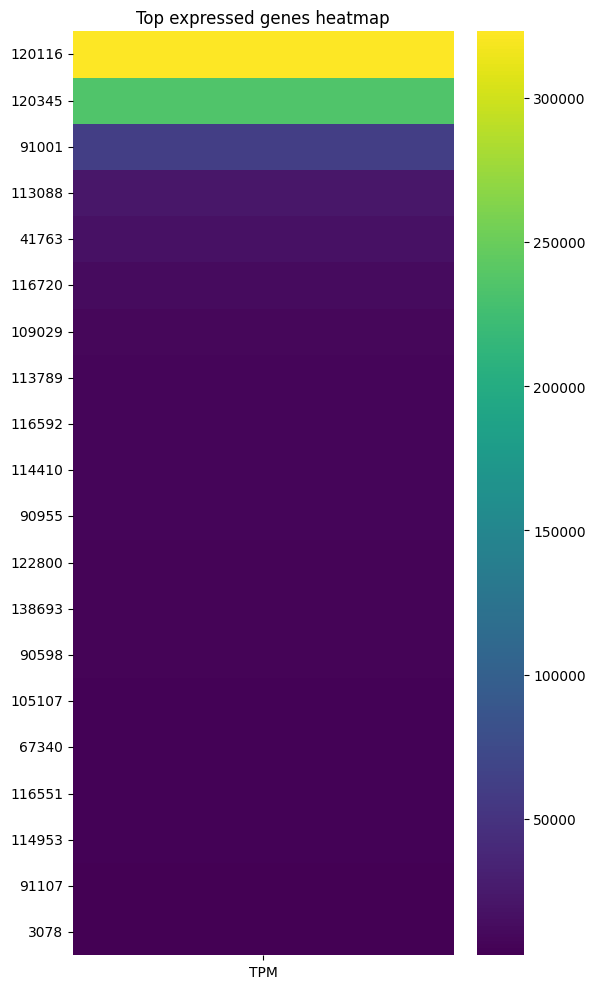

In [8]:
plt.figure(figsize=(6,10))

sns.heatmap(
    heatmap_data,
    cmap="viridis",
    annot=False
)

plt.title("Top expressed genes heatmap")
plt.tight_layout()

plt.savefig("figures/top_genes_heatmap.png", dpi=300)

plt.show()

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [10]:
expression_data = df[["TPM", "FPKM", "expected_count"]]

expression_scaled = StandardScaler().fit_transform(expression_data)

In [11]:
pca = PCA(n_components=2)

principal_components = pca.fit_transform(expression_scaled)

pca_df = pd.DataFrame(
    data=principal_components,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,0.151433,0.211506
1,-0.018252,-0.010883
2,-0.018252,-0.010883
3,-0.016925,-0.009276
4,-0.018252,-0.010883


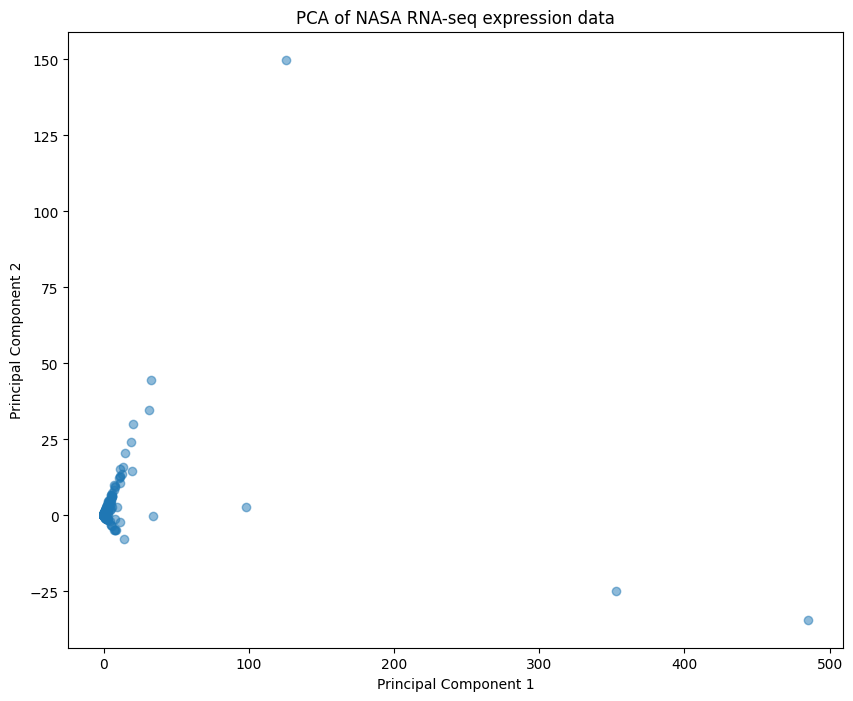

In [12]:
plt.figure(figsize=(10,8))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.title("PCA of NASA RNA-seq expression data")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.show()